
# Realtime Functionality
先pip install tropycal


In [1]:
%matplotlib inline

In [2]:
from tropycal import realtime
import datetime as dt
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
realtime_obj = realtime.Realtime(jtwc=True,jtwc_source='ucar')

--> Starting to read in current storm data
--> Completed reading in current storm data (46.4 seconds)


In [223]:
#realtime_obj = realtime.Realtime() (東太，北大西洋用）

--> Starting to read in current storm data
--> Completed reading in current storm data (1.74 seconds)


## Realtime Storms
To retrieve a storm from a Realtime object, simply use its ``get_storm()`` method and provide an ID as listed in ``list_active_storms()``:



In [4]:
realtime_obj

<tropycal.realtime.Realtime>
Dataset Summary:
    Numbers of active storms: 2
    Time Updated: 2039 UTC 07 April 2026

Active Storms:
    SH302026
    SH312026

Active Invests:

In [5]:
storm = realtime_obj.get_storm('SH302026')

This now returns a RealtimeStorm object. RealtimeStorm objects inherit the same functionality as Storm objects, but have additional functions unique to realtime storms. Additionally, as these can also be valid for invests, certain functionality that is only available for tropical cyclones (e.g., NHC forecasts or discussions) is unavailable for invests.

Let's view what this RealtimeStorm object contains:



In [6]:
import numpy as np
forecasts = storm.get_operational_forecasts()
y=print(forecasts.keys())
length=len(forecasts.keys())
#forecasts['AVNX']['2026030712']['lon']
keys = np.fromiter(forecasts.keys(), dtype=list)
keys_2=np.fromiter(forecasts[keys[i]].keys(),dtype=list)
keys_3=np.fromiter(forecasts[keys[i]][keys_2[-1]].keys(),dtype=list)
length=len(forecasts.keys())
#length
#df =storm.to_dataframe()
#df
#forecasts['NP15']['2026030700']['lon']
#無需理會run error

dict_keys(['CARQ', 'AC00', 'AEMN', 'AP01', 'AP02', 'AP03', 'AP04', 'AP05', 'AP06', 'AP07', 'AP08', 'AP09', 'AP10', 'AP11', 'AP12', 'AP13', 'AP14', 'AP15', 'AP16', 'AP17', 'AP18', 'AP19', 'AP20', 'AP21', 'AP22', 'AP23', 'AP24', 'AP25', 'AP26', 'AP27', 'AP28', 'AP29', 'AP30', 'AVNX', 'CC00', 'CEMN', 'CMC', 'CP01', 'CP02', 'CP03', 'CP04', 'CP05', 'CP06', 'CP07', 'CP08', 'CP09', 'CP10', 'CP11', 'CP12', 'CP13', 'CP14', 'CP15', 'CP16', 'CP17', 'CP18', 'CP19', 'CP20', 'NC00', 'NEMN', 'NGX', 'NP01', 'NP02', 'NP03', 'NP04', 'NP05', 'NP06', 'NP07', 'NP08', 'NP09', 'NP10', 'NP11', 'NP12', 'NP13', 'NP14', 'NP16', 'NP17', 'NP18', 'NP19', 'NP20', 'UKM', 'CHIP', 'CHP2', 'CHP3', 'CHP4', 'CHP5', 'CHP6', 'CHP7', 'NP15'])


NameError: name 'i' is not defined

--> Starting to calculate track density
--> Completed calculating track density (9.3 seconds)


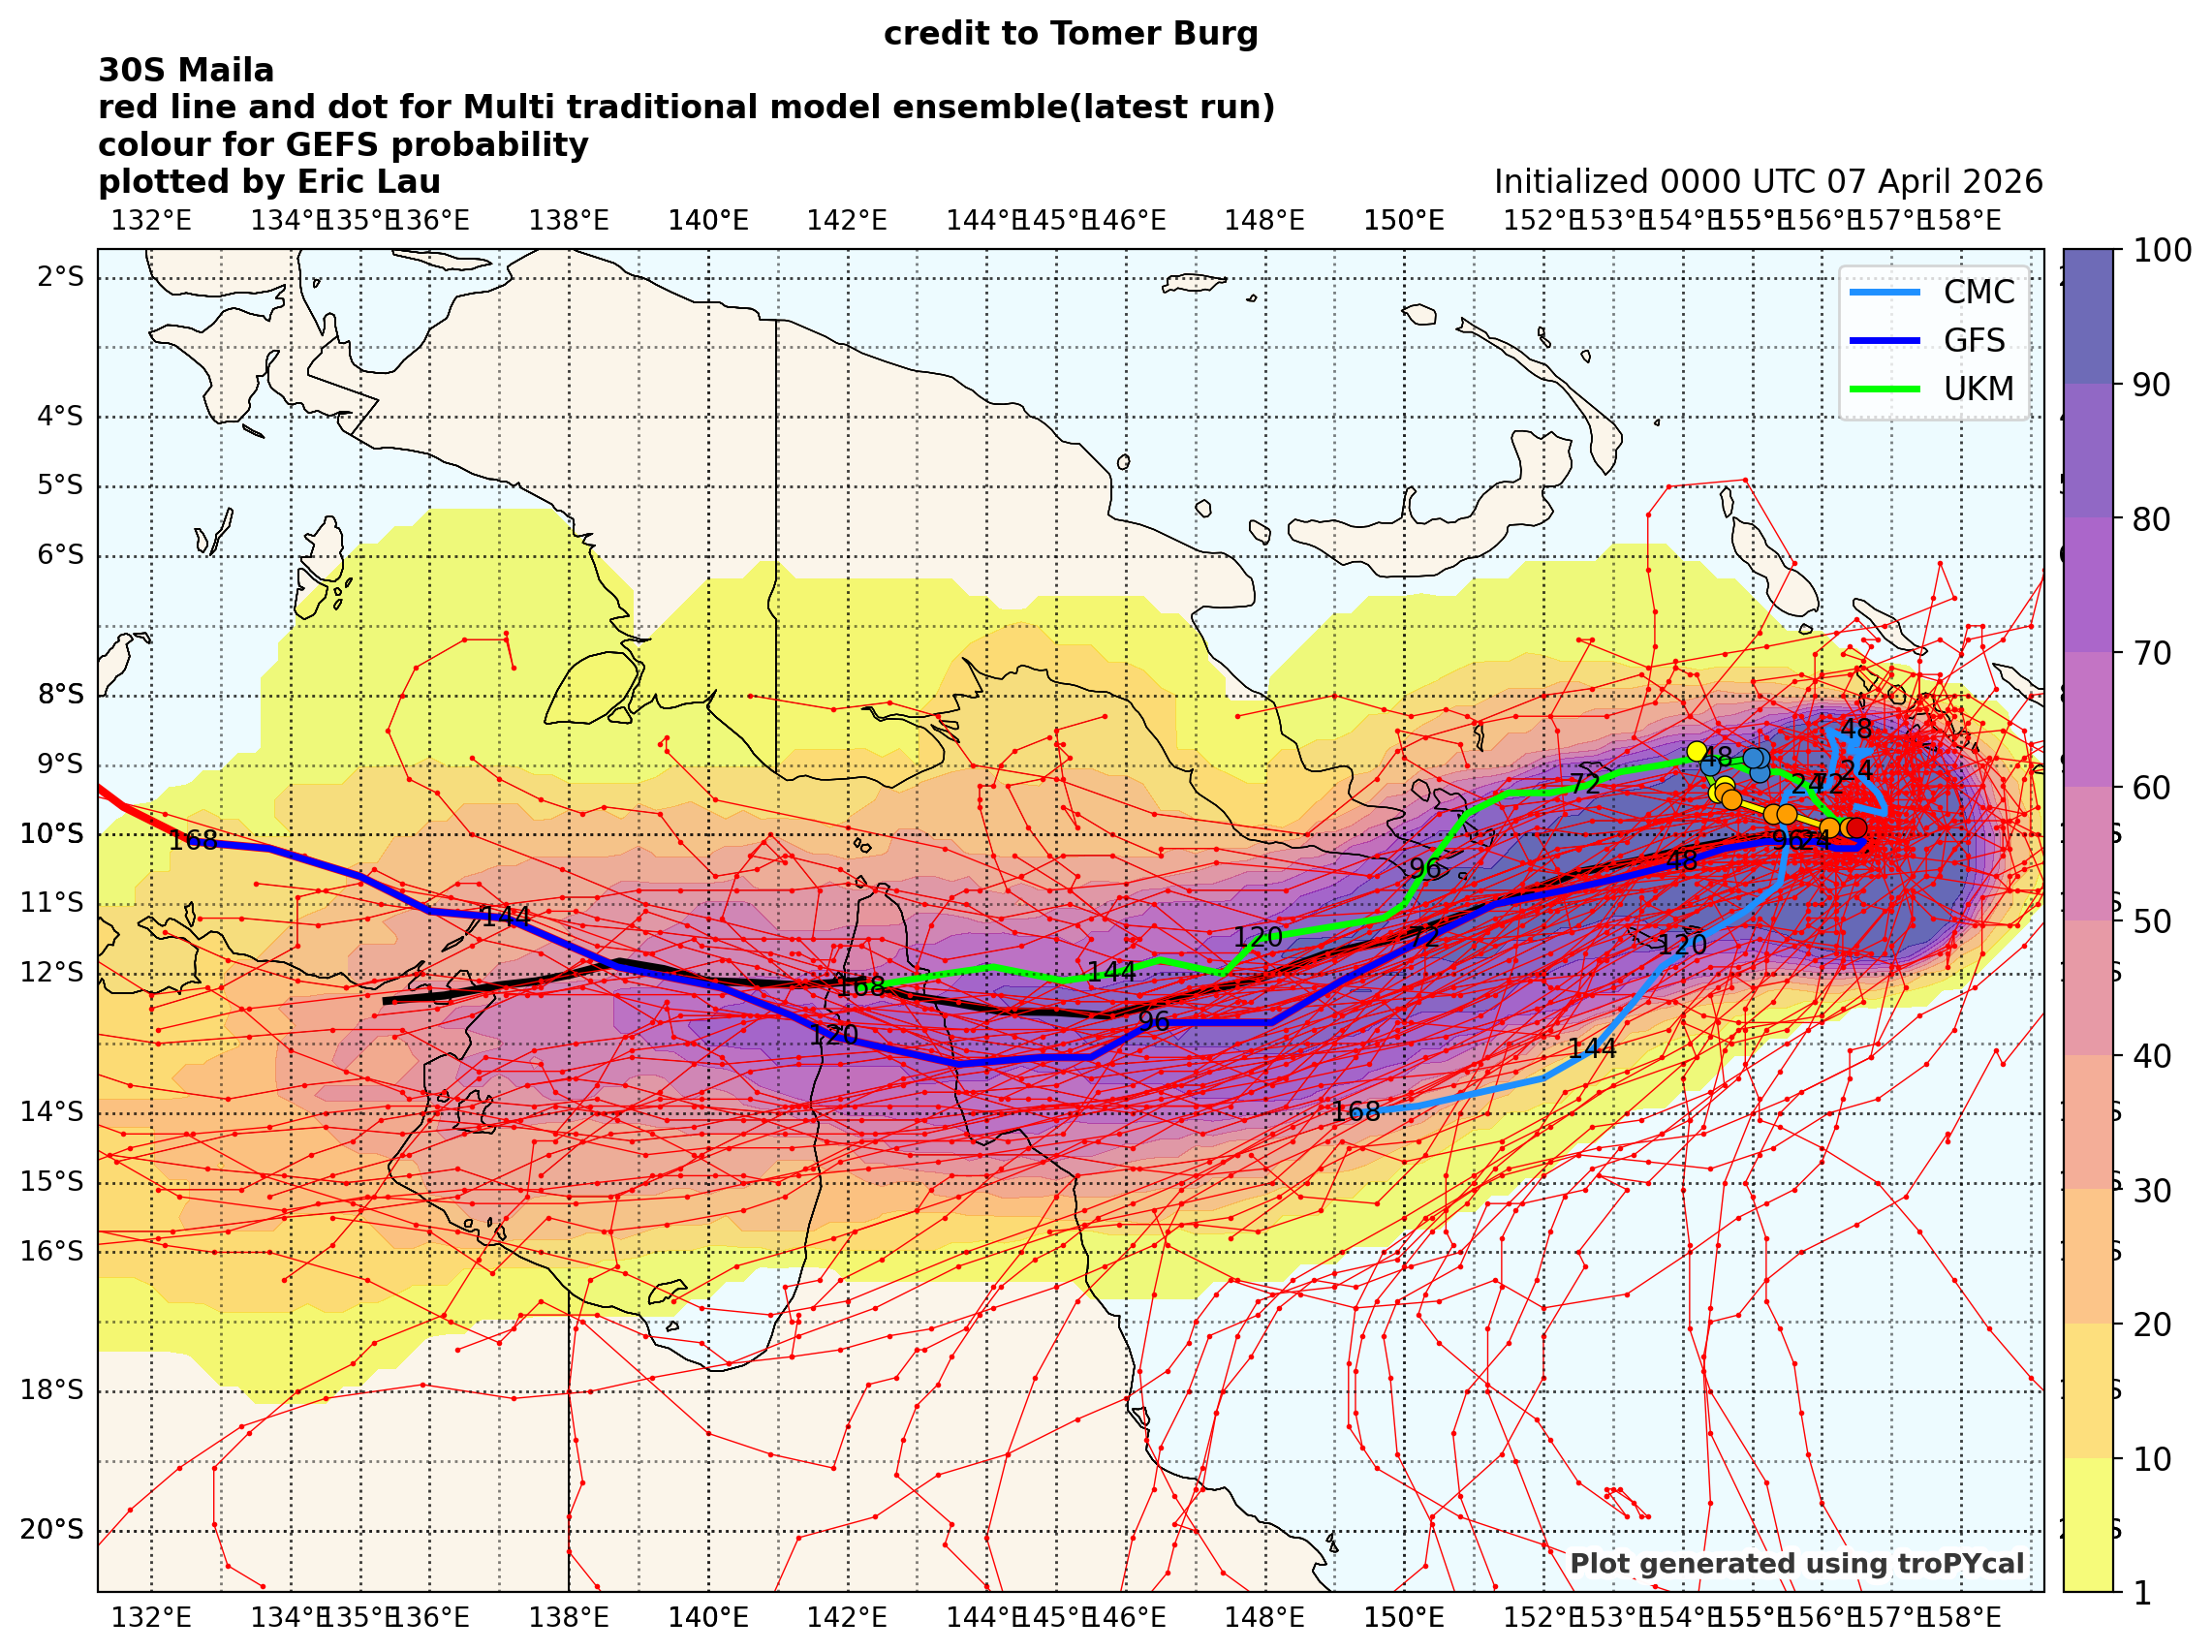

In [12]:
import numpy as np
import seaborn as sns
import pandas as pd
from scipy.interpolate import griddata
init=dt.datetime(2026,4,7,0)#時間
#ax=storm.plot_models()
#y=storm.interp(hours=3)
#y
ax1=storm.plot_ensembles(forecast=init,fhr=None,cmap="gist_ncar",radius=200)
cmap = 'gist_ncar'
ax2=storm.plot(ax=ax1,forecast=init,prop={
    'dots' : True,
    'linecolor':'vmax',
    'cmap' : cmap,
    'linewidth' : 2,
    'levels' : (0,170),
    'res':'h',
})
for i in np.arange(0,length-1):
    keys = np.fromiter(forecasts.keys(), dtype=list)
    keys_2=np.fromiter(forecasts[keys[i]].keys(),dtype=list)
    #length
    ax2.plot(np.array(forecasts[keys[i]][keys_2[-1]]['lon'])-180,forecasts[keys[i]][keys_2[-1]]['lat'],'o-',ms=1,color='red',linewidth=0.5)#如發現紅點及線沒出現，lon-180
ax3=storm.plot_models(forecast=init,ax=ax2)

ax3.set_title(f'credit to Tomer Burg\n\n\n\n',loc='center',fontweight='bold')
ax3.set_title(f'30S Maila\nred line and dot for Multi traditional model ensemble(latest run)\ncolour for GEFS probability\nplotted by Eric Lau',loc='left',color='k',fontweight='bold')
ax3.tissot(rad_km=(800), lons=[114.175], lats=[22.3], alpha=0.3,color=None,linewidth=1,edgecolor='black',)
ax3.tissot(rad_km=(400), lons=[114.175], lats=[22.3], alpha=0.3,color=None,linewidth=1,edgecolor='yellow')
ax3.tissot(rad_km=(200), lons=[114.175], lats=[22.3], alpha=0.3,color=None,linewidth=1,edgecolor='orange')
ax3.tissot(rad_km=(100), lons=[114.175], lats=[22.3], alpha=0.3,color=None,linewidth=1,edgecolor='red')
plt.show()

A quick and easy way to check if a storm is an invest is by checking its ``invest`` attribute. This will let you know if you can use the full set of functionality available for tropical cyclones or not.



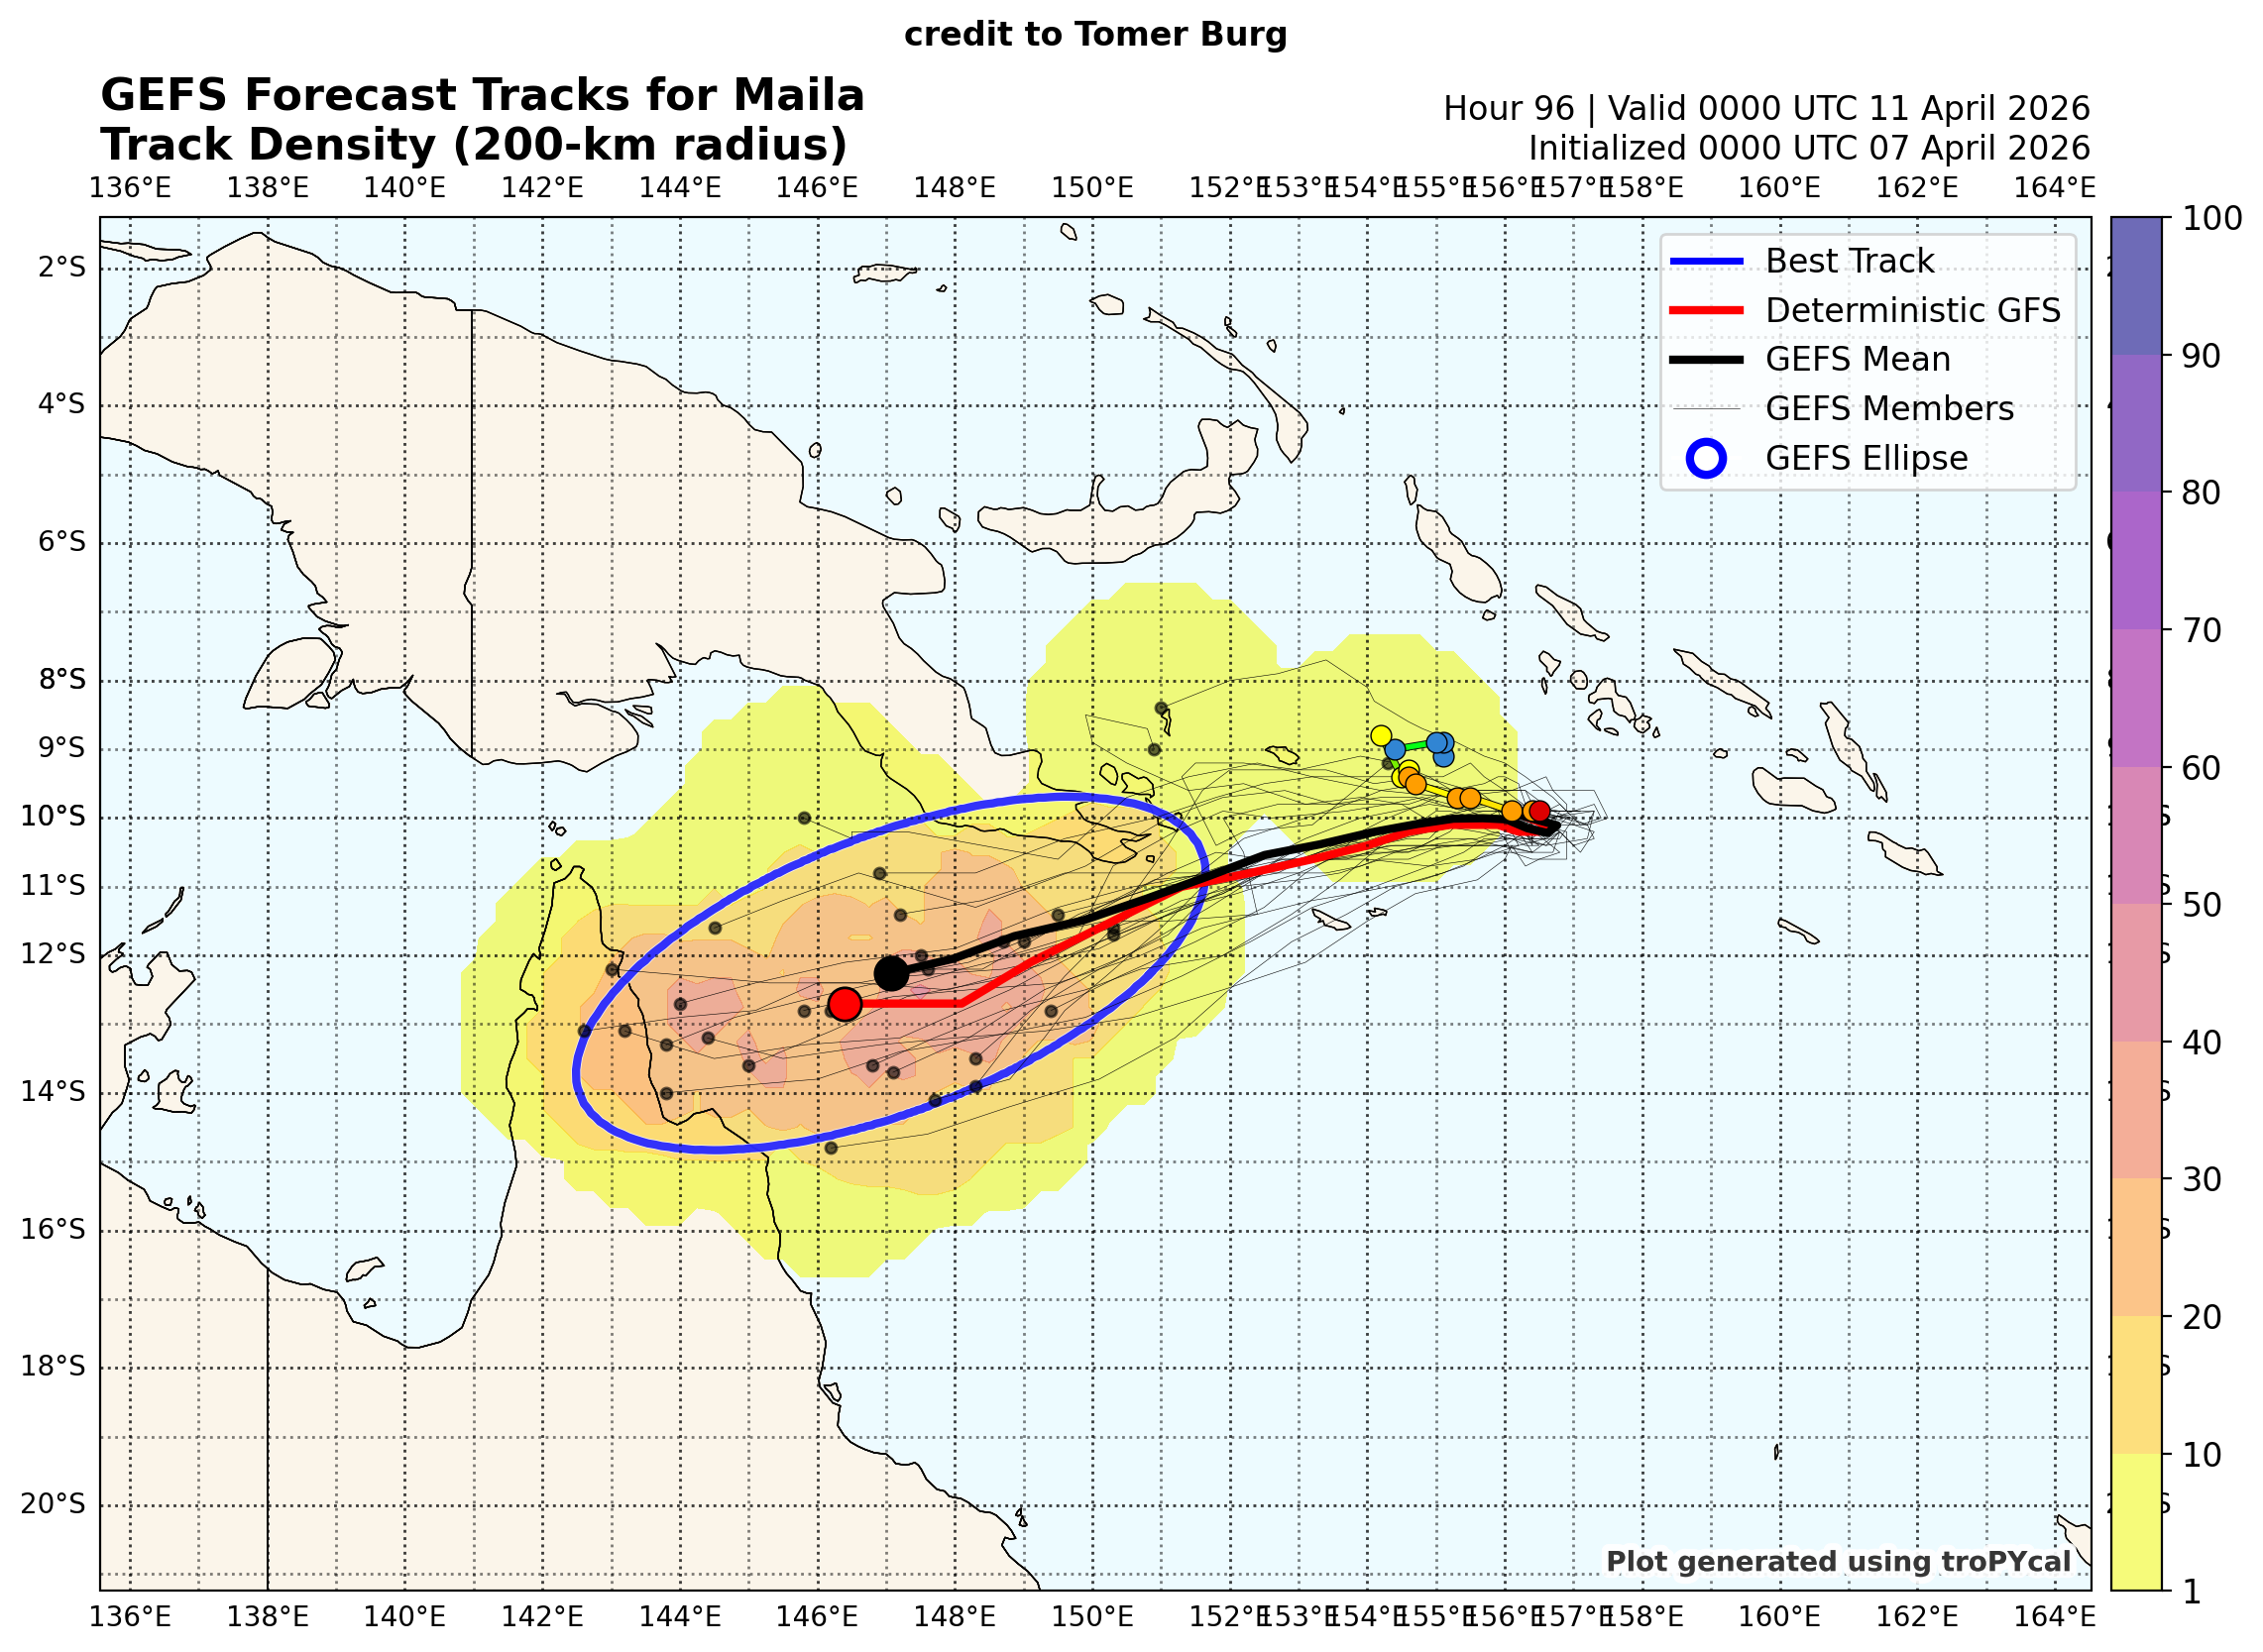

In [20]:
#storm.to_dict()
cmap = 'gist_ncar'
init=dt.datetime(2026,4,7,0)
ax=storm.plot(domain='dynamic_tropical',
    prop={
    'dots' : True,
    'linecolor':'vmax',
    'cmap' : cmap,
    'linewidth' : 2,
    'levels' : (0,170),
    'res':'h',
})
ax2=storm.plot_ensembles(ax=ax,forecast=init,fhr=96,prop_density={'radius':200})
#ax3=storm.plot_forecast_realtime(ax=ax2)
#ax.set_extent([100,140,5,30])
ax.set_title(f'credit to Tomer Burg\n\n\n',loc='center',fontweight='bold')
#ax2.set_title('Eric:\n1 min sustained wind: 25kts\n 10 min sustained wind:40km/h\nMSLP:1000hPa',loc='right')
plt.show()

The next few blocks will overview functions unique to RealtimeStorm objects. We can easily retrieve the latest available forecast dictionary from NHC or JTWC, depending on what area of responsibility the storm is in.

This function also calculates the forecast Accumulated Cyclone Energy (ACE), derived by combining its observed ACE through the current time plus the forecast ACE using linearly interpolated forecast sustained wind.



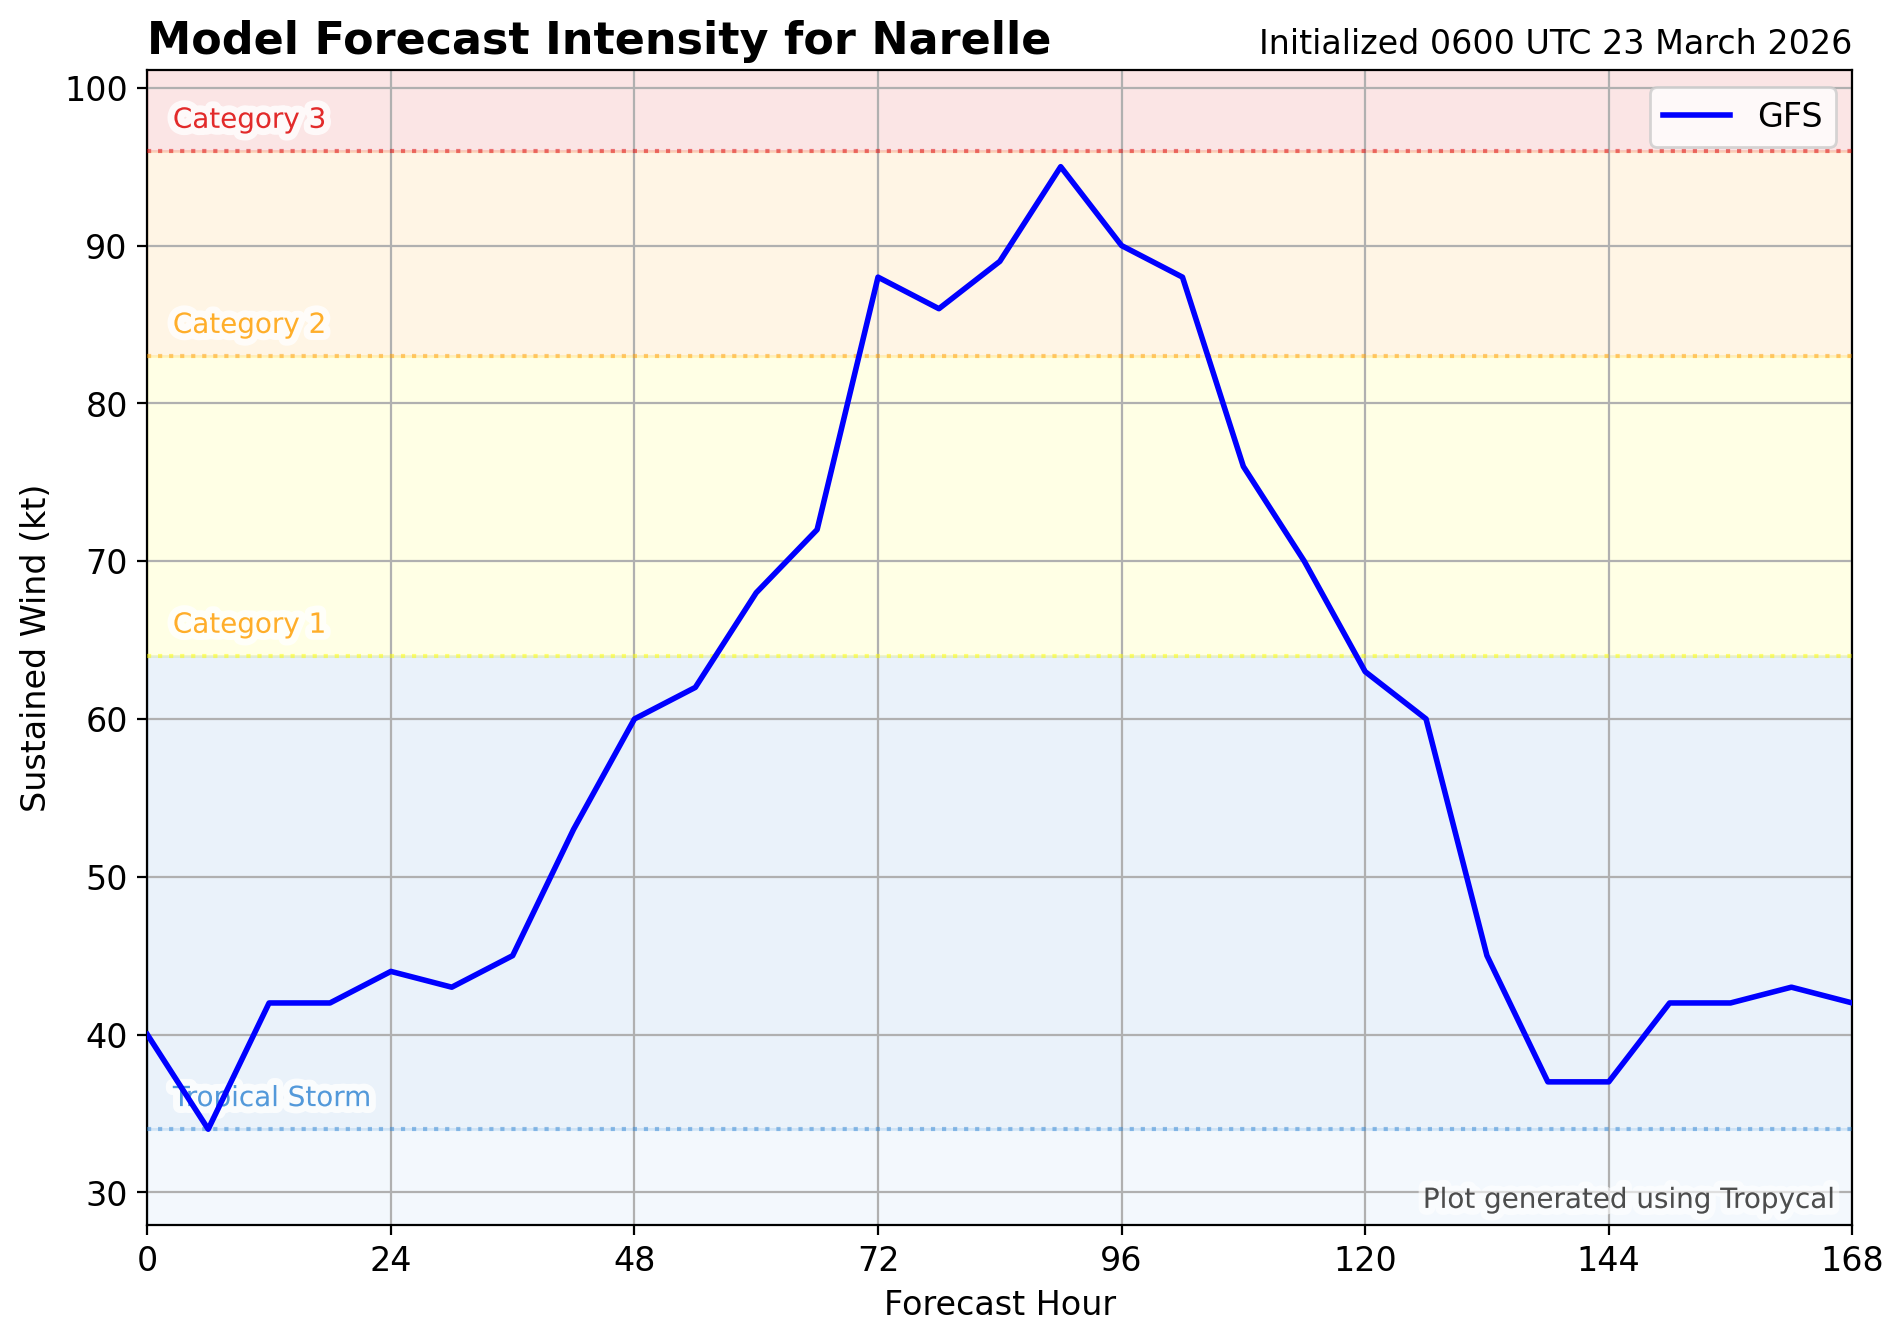

In [18]:
storm.plot_models_wind(forecast=init)
plt.show()

We can also plot it using the ``plot_forecast_realtime()`` method:



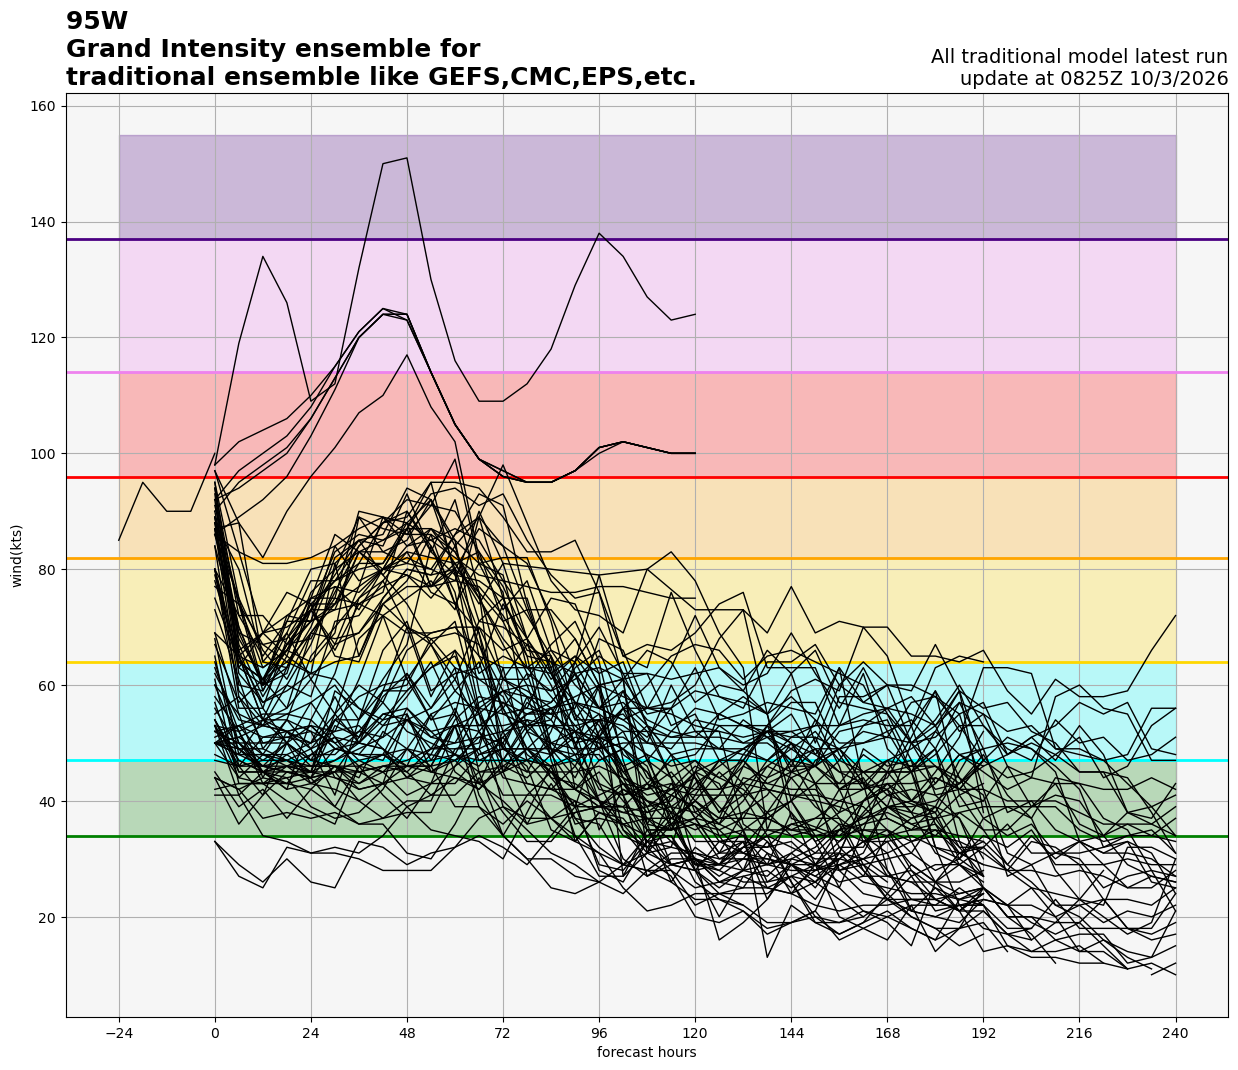

In [ ]:
# Create figure
import math
import numpy as np
import seaborn as sns
from scipy.stats import gaussian_kde
#df_1=pd.read_csv(f'/Users/eknlau/Downloads/FNV3_11_8_18Z.csv')
#df_1=pd.DataFrame(df_1)
#condition_1=df_1['new_track_id']==False
#condition_2=df_1['hours']>120
#rows_to_drop = df_1[condition_1|condition_2].index
#df_cleaned = df_1.drop(rows_to_drop)
fig = plt.figure(figsize=(15,12))
ax = plt.axes()
#                          subplot_kw={'projection': crs})
#add_metpy_logo(fig, 140, 120, size='small')

ax.set_facecolor('#f6f6f6')
ax.grid()
ax.set_ylabel("wind speed(kts)")
ax.set_xlabel("forecast hours")
#ax.plot(ships.fhr, ships.vmax_noland_kt, color='red', linewidth=2.5)
ax.set_title(f"95W \nGrand Intensity ensemble for\ntraditional ensemble like GEFS,CMC,EPS,etc.",
             loc='left', fontsize=18, fontweight='bold')
ax.set_title(f"All traditional model latest run\nupdate at 0825Z 10/3/2026",
             loc='right', fontsize=14)
gale=34
ax.axhline(gale,color='green', lw=2)
ax.fill_between(range(-24,241),34,47,color='green',alpha=0.25)
sts=47
ax.axhline(sts,color='cyan', lw=2)
ax.fill_between(range(-24,241),47,64,color='cyan',alpha=0.25)
c1=64
ax.axhline(c1,color='gold', lw=2)
ax.fill_between(range(-24,241),64,82,color='gold',alpha=0.25)
c2=82
ax.axhline(c2,color='orange', lw=2)
ax.fill_between(range(-24,241),82,96,color='orange',alpha=0.25)
c3=96
ax.axhline(c3,color='red', lw=2)
ax.fill_between(range(-24,241),96,114,color='red',alpha=0.25)
c4=114
ax.axhline(c4,color='violet', lw=2)
ax.fill_between(range(-24,241),114,137,color='violet',alpha=0.25)
c5=137
ax.axhline(c5,color='indigo', lw=2)
ax.fill_between(range(-24,241),137,155,color='indigo',alpha=0.25)
for i in np.arange(0,length-1):
    keys = np.fromiter(forecasts.keys(), dtype=list)
    keys_2=np.fromiter(forecasts[keys[i]].keys(),dtype=list)
    ax.plot(forecasts[keys[i]][keys_2[-1]]['fhr'],forecasts[keys[i]][keys_2[-1]]['vmax'],color='k',linewidth=1)
ax.set_xticks(np.arange(-24,241,24))

ax.set_ylabel("wind(kts)")
ax.set_xlabel("forecast hours")
plt.show()

FNV3 probability
重要提示：save FNV3 probability nc file 步驟會佔用2GB空間

In [ ]:
from PIL import Image
from urllib.request import urlopen
import datetime as dt
from tropycal import tracks, utils
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr

In [ ]:
proj = ccrs.PlateCarree()
import matplotlib.font_manager
matplotlib.rcParams['font.family'] = ['PingFang HK']

# Create an instance of figure and axes
fig = plt.figure(figsize=(9,6),dpi=200)
ax = plt.axes(projection=proj)

# Plot coastlines and political boundaries
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidths=0.5, linestyle='solid', edgecolor='k')
ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidths=1.0, linestyle='solid', edgecolor='k')
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidths=1.0, linestyle='solid', edgecolor='k')

# Fill in continents in light gray
ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='#EEEEEE', edgecolor='face')
# Zoom in over the Gulf Coast
ax.set_extent([100,140,7,36])
plt.show()

In [ ]:
def plot_boundaries(ax):
    """This function plots geographic and political boundaries on the provided axes."""
    
    # Plot coastlines and political boundaries
    ax.add_feature(cfeature.STATES.with_scale('10m'), linewidths=0.5, linestyle='solid', edgecolor='k')
    ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidths=1.0, linestyle='solid', edgecolor='k')
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidths=1.0, linestyle='solid', edgecolor='k')
    #ax.add_feature(cfeature.OCEAN)
    ax.tissot(rad_km=(800), lons=[114.174], lats=[22.302], alpha=0.2,color=None,linewidth=1,edgecolor='black')
    ax.tissot(rad_km=(400), lons=[114.174], lats=[22.302], alpha=0.2,color=None,linewidth=1,edgecolor='yellow')
    ax.tissot(rad_km=(200), lons=[114.174], lats=[22.302], alpha=0.2,color=None,linewidth=1,edgecolor='orange')
    ax.tissot(rad_km=(100), lons=[114.174], lats=[22.302], alpha=0.2,color=None,linewidth=1,edgecolor='red')

    # Fill in continents in light gray
    ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='#EEEEEE', edgecolor='face')
    #ax.set_extent([105,125,15,30])
    # Return axes instance
    return ax

In [ ]:
import base64
import gzip

#download FNV3 Large ensemble probability cumulated probability from google weather lab website
with open('自行改input file path','r') as f:
    try:    
        encoded_data = f.read()
    except Exception as e:
    # Handle the error
        print(f"An error occurred: {e}. Skipping operation.")
        pass 
# 1. Decode Base64 to Gzip bytes
compressed_data = base64.b64decode(encoded_data)

# 2. Decompress Gzip to original NetCDF bytes
original_data = gzip.decompress(compressed_data)

# 3. Write to .nc file
with open('自行改output file path', 'wb') as f:
    f.write(original_data)

In [ ]:
data=xr.open_dataset(f'output path')
data

In [ ]:
from matplotlib import cm
fig = plt.figure(figsize=(9,6),dpi=200)
ax2 = plt.axes(projection=proj) # We already defined "proj" earlier, so no need to redefine it
ax2 = plot_boundaries(ax2)
ds_1=data.sel(lat=slice(0, 50), lon=slice(100, 170))
lon_2d,lat_2d=np.meshgrid(ds_1.lon,ds_1.lat)
ds_2=np.array(ds_1['track_probability'][60]).reshape(201,281)
g=ax2.contourf(lon_2d,lat_2d,ds_2,levels=np.arange(0.01,1,0.01),cmap='gist_ncar',transform=proj)
q=fig.colorbar(g, orientation='horizontal', shrink=0.74, pad=0)
q.set_label(f'probability')
gl=ax2.gridlines(draw_labels=True)
gl.xlabels_top = False
gl.ylabels_left = False
ax2.set_extent([100,170,0,50])
ax2.set_title(f'FNV3 Large ensemble 15 days 20260406 18Z TC track probability plot\nVisualized by Eric Lau')
plt.show()